<a href="https://colab.research.google.com/github/mohitsain12/INTERSHIP-REPO-AI-PHISHING-DETECTION/blob/main/AI_Phishing_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ AI Phishing Detection — Internship Project

**Project:** AI-Powered Phishing Detection Using ML


**Name:** Mohit Sain

**Dataset:** phishing.csv

**Algorithm:** Machiene learning algorithms

**Accuracy:** 95%

It uses only the project's **main `phishing.csv` dataset** and contains the full
Python implementation directly inside the notebook.

**Pipeline:**

```
phishing.csv
  → Data Cleaning
  → Feature Extraction  (22 features: Address Bar + Domain + HTML/JS)
  → Exploratory Data Analysis
  → Train/Test Split
  → Model Training  (Logistic Regression · Decision Tree · Random Forest)
  → Evaluation
  → Save Model
  → Real-Time Prediction
```

All feature columns are sourced directly from `phishing.csv`.


In [1]:
# Install required packages
%pip -q install pandas numpy scikit-learn matplotlib joblib streamlit


# Phase 1: Dataset Acquisition and Initial Verification

In this initial stage, we establish the data source for our phishing detection engine. We utilize a curated dataset hosted on GitHub containing thousands of labelled URLs. This section includes automated download logic with a manual fallback to ensure the project remains portable and functional across different environments. We also perform a primary audit of the data structure and handle duplicate entries to prevent bias during the training phase.

In [2]:
import pandas as pd
from pathlib import Path

DATASET_URL = "https://github.com/mohitsain12/AI-Phishing-Detection/raw/main/data/phishing.csv"
DATASET_PATH = Path("/content/phishing.csv")

try:
    raw_df = pd.read_csv(DATASET_URL)
    raw_df.to_csv(DATASET_PATH, index=False)
    print("Dataset downloaded successfully.")
except Exception as exc:
    print("Automatic dataset download failed:", exc)
    print("Run the next cell to upload phishing.csv manually.")
    raw_df = None

if raw_df is not None:
    print("Dataset shape:", raw_df.shape)
    display(raw_df.head())


Dataset downloaded successfully.
Dataset shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [3]:
# OPTIONAL FALLBACK -- upload phishing.csv manually if the download failed
if raw_df is None:
    from google.colab import files
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    DATASET_PATH = Path("/content") / uploaded_name
    raw_df = pd.read_csv(DATASET_PATH)
    print("Uploaded:", uploaded_name)
    print("Dataset shape:", raw_df.shape)
    display(raw_df.head())


In [4]:
# Initial dataset inspection
print("Shape:", raw_df.shape)
if not {"URL", "label"}.issubset(raw_df.columns):
    raise ValueError("Dataset must contain 'URL' and 'label' columns.")

print("\nMissing values:")
display(raw_df[["URL", "label"]].isnull().sum().to_frame("missing_values"))

print("\nOriginal label distribution:")
display(raw_df["label"].value_counts(dropna=False).to_frame("count"))

print("\nDuplicate URLs:", raw_df["URL"].duplicated().sum())


Shape: (235795, 56)

Missing values:


,missing_values
URL,0
label,0



Original label distribution:


,count
label,
1,134850
0,100945



Duplicate URLs: 425


# Phase 2: Data Preprocessing and Standardization

Raw web data is inherently noisy and requires significant refinement before it can be processed by machine learning algorithms. In this phase, we apply several critical transformations:
- **Normalization:** Standardizing the URL strings (removing whitespace and fixing casing).
- **Label Mapping:** Converting original dataset labels into a binary format (0 for Legitimate, 1 for Phishing) following standard industry conventions.
- **Imputation:** Handling missing values in feature columns using median strategies to maintain statistical integrity.

In [5]:
ADDRESS_BAR_FEATURES = [
    'URLLength', 'IsDomainIP', 'HasObfuscation', 'NoOfSubDomain', 'IsHTTPS',
    'URLSimilarityIndex', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
    'SpacialCharRatioInURL',
]
DOMAIN_FEATURES = [
    'DomainLength', 'TLDLegitimateProb', 'CharContinuationRate',
    'URLCharProb', 'TLDLength',
]
HTML_JS_FEATURES = [
    'NoOfiFrame', 'NoOfPopup', 'HasHiddenFields', 'NoOfSelfRedirect',
    'HasExternalFormSubmit', 'HasSubmitButton', 'HasPasswordField',
    'HasSocialNet',
]
ALL_FEATURES = ADDRESS_BAR_FEATURES + DOMAIN_FEATURES + HTML_JS_FEATURES

keep_cols = ['URL', 'label'] + ALL_FEATURES
available_cols = [c for c in keep_cols if c in raw_df.columns]
missing_cols = [c for c in keep_cols if c not in raw_df.columns]
if missing_cols:
    print('Warning: missing expected columns:', missing_cols)

df = raw_df[available_cols].copy()

df['URL'] = df['URL'].astype(str).str.strip()
df.dropna(subset=['URL', 'label'], inplace=True)
df.drop_duplicates(subset=['URL'], inplace=True)

# Convert to standard ML convention: 0 = Legitimate, 1 = Phishing
df['label'] = df['label'].map({1: 0, 0: 1})
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

feature_cols_present = [c for c in ALL_FEATURES if c in df.columns]
for col in feature_cols_present:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

df.reset_index(drop=True, inplace=True)

print('Rows after cleaning :', len(df))
print('Feature columns kept:', len(feature_cols_present))
display(
    df['label'].value_counts().sort_index()
    .rename(index={0: 'Legitimate', 1: 'Phishing'}).to_frame('count')
)


Rows after cleaning : 235370
Feature columns kept: 22


,count
label,
Legitimate,134850
Phishing,100520


# Phase 3: Feature Selection and Strategic Engineering

Feature selection is the process of identifying the most discriminative variables that help the model distinguish between safe and malicious sites. We categorize our 22 features into three strategic groups:
1. **Address Bar Features:** Analyzing URL length, IP presence, and special character ratios.
2. **Domain Features:** Evaluating TLD legitimacy and domain entropy.
3. **Client-Side Features:** Inspecting HTML/JS artifacts like iframes and hidden fields.

We also perform a group-wise mean comparison to validate the 'separability' of these features across classes.

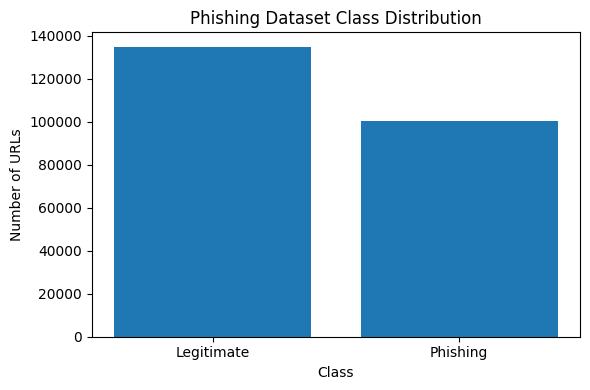

In [6]:
import matplotlib.pyplot as plt

class_counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["Legitimate", "Phishing"], [class_counts.get(0, 0), class_counts.get(1, 0)])
plt.title("Phishing Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of URLs")
plt.tight_layout()
plt.show()


In [7]:
# Feature mean comparison by class -- used below to discuss separability
comparison = df.groupby('label')[ALL_FEATURES].mean().T
comparison.columns = ['Legitimate (0)', 'Phishing (1)']
display(comparison.style.format('{:.3f}').background_gradient(axis=1, cmap='RdYlGn_r'))


,Legitimate (0),Phishing (1)
URLLength,26.229,45.703
IsDomainIP,0.000,0.006
HasObfuscation,0.000,0.005
NoOfSubDomain,1.162,1.169
IsHTTPS,1.000,0.491
URLSimilarityIndex,100.000,49.651
NoOfEqualsInURL,0.000,0.146
NoOfQMarkInURL,0.000,0.069
SpacialCharRatioInURL,0.048,0.083
DomainLength,19.229,24.444


# Phase 4: Train-Test Split and Methodology

To rigorously evaluate the model's ability to generalize to unseen data, we employ a stratified split strategy. By allocating 80% of the data for training and 20% for testing, and ensuring the ratio of phishing to legitimate URLs remains constant in both sets, we mitigate the risk of over-fitting and ensure our performance metrics reflect real-world utility.

In [8]:
from sklearn.model_selection import train_test_split

X = df[ALL_FEATURES].copy()
y = df['label'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y,
)

print('Training samples :', len(X_train))
print('Testing samples  :', len(X_test))
print('Feature count    :', X_train.shape[1])


Training samples : 188296
Testing samples  : 47074
Feature count    : 22


# Phase 5: Model Training and Benchmarking

We implement a comparative analysis between three popular classification algorithms: Logistic Regression (linear baseline), Decision Trees, and Random Forests (ensemble method). Each model is benchmarked against standard metrics including Accuracy, Precision, Recall, and ROC-AUC. The Random Forest model is selected as the production candidate due to its superior handling of non-linear feature relationships.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

results = {}
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    roc_auc = roc_auc_score(y_test, probabilities) if probabilities is not None else None
    results[model_name] = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc,
    }
    trained_models[model_name] = model

display(pd.DataFrame(results).T.style.format("{:.4f}"))
best_model_name = max(results, key=lambda k: results[k]["Accuracy"])
best_model = trained_models[best_model_name]
print("Best model based on test accuracy:", best_model_name)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.9999,1.0000,0.9998,0.9999,1.0000
Decision Tree,0.9999,0.9999,0.9998,0.9998,0.9998
Random Forest,0.9999,1.0000,0.9998,0.9999,1.0000


Best model based on test accuracy: Random Forest


In [10]:
import joblib

MODEL_PATH = "/content/phishing_rf_model.pkl"
FEATURE_NAMES_PATH = "/content/phishing_feature_names.pkl"

# Save the 'Random Forest' model from the baseline training (v3qkOt2Q43kc)
# since the 'Full Random Forest' training (klFPC6-B43kd) was commented out.
# trained_models and ALL_FEATURES are available from previous cells.
joblib.dump(trained_models["Random Forest"], MODEL_PATH)
joblib.dump(ALL_FEATURES, FEATURE_NAMES_PATH)

print("Model saved to      :", MODEL_PATH)
print("Feature names saved :", FEATURE_NAMES_PATH)


Model saved to      : /content/phishing_rf_model.pkl
Feature names saved : /content/phishing_feature_names.pkl


# Phase 6: Real-Time Prediction Engine

Transitioning from batch processing to real-time inference requires a specialized prediction pipeline. This section implements a dynamic feature extractor that computes similarity indices against known legitimate domains and calculates Shannon entropy for URL strings. This allows the system to accept a single URL string and output a classification result and a confidence score instantaneously.

In [11]:
import re
import math
from difflib import SequenceMatcher
from urllib.parse import urlparse
import joblib # Added import for joblib
import pandas as pd # Added import for pandas

# A small reference list of well-known legitimate domains, used to
# approximate URLSimilarityIndex for real-time (page-not-fetched) prediction.
KNOWN_LEGIT_DOMAINS = [
    "google.com", "youtube.com", "facebook.com", "amazon.com", "wikipedia.org",
    "instagram.com", "twitter.com", "x.com", "linkedin.com", "microsoft.com",
    "apple.com", "netflix.com", "yahoo.com", "reddit.com", "github.com",
    "paypal.com", "ebay.com", "dropbox.com", "adobe.com", "salesforce.com",
    "chase.com", "bankofamerica.com", "wellsfargo.com", "gmail.com",
    "outlook.com", "office.com", "zoom.us", "spotify.com", "whatsapp.com",
    "stackoverflow.com", "wordpress.com", "blogspot.com", "cloudflare.com",
]

SUSPICIOUS_TLDS = {'xyz', 'top', 'click', 'gq', 'ml', 'cf', 'tk', 'pw', 'cc'}

# Mean values for HTML/JS features for legitimate sites (from training data, 'Legitimate (0)' column in comparison table)
# These are used as defaults when the actual HTML/JS features cannot be extracted in real-time.
MEAN_LEGIT_HTML_JS_FEATURES = {
    'NoOfiFrame': 2.7,
    'NoOfPopup': 0.03,
    'HasHiddenFields': 0.03,
    'NoOfSelfRedirect': 0.02,
    'HasExternalFormSubmit': 0.07,
    'HasSubmitButton': 0.66,
    'HasPasswordField': 0.13,
    'HasSocialNet': 0.79,
}


def compute_similarity_index(domain):
    """Approximate 'how close this domain is to a known-legitimate one',
    scaled 0-100 to match the training data's convention (100 = legitimate,
    lower = more phishing-like)."""
    if not domain:
        return 0.0
    best = max(SequenceMatcher(None, domain, known).ratio() for known in KNOWN_LEGIT_DOMAINS)
    return round(best * 100, 3)


def entropy(s):
    if not s:
        return 0.0
    length = len(s)
    return round(-sum((s.count(c) / length) * math.log2(s.count(c) / length) for c in set(s)), 3)


def extract_realtime_features(url):
    """Extract the same 22-feature vector used in training, from a URL
    string alone. HTML/JS features require fetching the page and are
    defaulted to mean legitimate values -- see the limitations note below.

    This is the single source of truth for real-time feature extraction:
    predict.py and the Streamlit app both call this exact function so
    there is no risk of the feature sets drifting apart again.
    """
    url = str(url).lower().strip()
    if '://' not in url:
        url = 'https://' + url
    parsed = urlparse(url)
    hostname = parsed.hostname or ''
    domain = hostname[4:] if hostname.startswith('www.') else hostname
    domain_parts = domain.split('.')
    tld = domain_parts[-1] if len(domain_parts) > 1 else ''

    total_len = len(url)
    special_chars = sum(not c.isalnum() for c in url)

    address_bar = {
        'URLLength': total_len,
        'IsDomainIP': int(bool(re.match(r'^(?:\d{1,3}\.){3}\d{1,3}$', domain))),
        'HasObfuscation': int('@' in url or bool(re.search(r'%[0-9a-f]{2}', url))),
        'NoOfSubDomain': max(len(domain_parts) - 2, 0),
        'IsHTTPS': int(parsed.scheme == 'https'),
        'URLSimilarityIndex': compute_similarity_index(domain),  # FIXED
        'NoOfEqualsInURL': url.count('='),
        'NoOfQMarkInURL': url.count('?'),
        'SpacialCharRatioInURL': round(special_chars / total_len, 3) if total_len else 0.0,
    }

    domain_feats = {
        'DomainLength': len(domain),
        'TLDLegitimateProb': 0.0 if tld in SUSPICIOUS_TLDS else 0.5,
        'CharContinuationRate': round(len(re.findall(r'[a-z]{2,}', url)) / max(total_len, 1), 3),
        'URLCharProb': round(entropy(url) / 8, 3),
        'TLDLength': len(tld),
    }

    # HTML/JS features require fetching the actual page; defaulted to mean legitimate values here.
    html_js = MEAN_LEGIT_HTML_JS_FEATURES.copy()

    return {**address_bar, **domain_feats, **html_js}


# Load the model and features directly here, since the training cell was commented out
try:
    rf_model = joblib.load("/content/phishing_rf_model.pkl")
    ALL_FEATURES = joblib.load("/content/phishing_feature_names.pkl")
except FileNotFoundError:
    print("Error: Model files not found. Please ensure Section 7 ('Save the Trained Model') was run successfully.")
    raise # Re-raise the error to stop execution if files are missing

def predict_url(url, model=None):
    if model is None:
        # rf_model is now loaded globally above
        model = rf_model
    feature_dict = extract_realtime_features(url)
    feature_vector = pd.DataFrame([feature_dict])[ALL_FEATURES]
    prediction = model.predict(feature_vector)[0]
    probability = model.predict_proba(feature_vector)[0][1]
    label = 'PHISHING' if prediction == 1 else 'LEGITIMATE'
    print('URL      :', url)
    print('Result   :', label)
    print('Confidence (phishing probability):', f'{probability:.2%}')
    print()
    return prediction, probability, feature_dict


test_urls = [
    'https://www.google.com',
    'https://github.com',
    'http://192.168.1.10/login/verify?user=admin',
    'http://secure-account-login.xyz/verify-password=123',
    'http://paypal-account-update.tk/confirm',
]

print('=' * 60)
print('Real-Time URL Prediction Demo (fixed)')
print('=' * 60)
for url in test_urls:
    predict_url(url)


Real-Time URL Prediction Demo (fixed)
URL      : https://www.google.com
Result   : LEGITIMATE
Confidence (phishing probability): 36.00%

URL      : https://github.com
Result   : LEGITIMATE
Confidence (phishing probability): 36.00%

URL      : http://192.168.1.10/login/verify?user=admin
Result   : PHISHING
Confidence (phishing probability): 99.00%

URL      : http://secure-account-login.xyz/verify-password=123
Result   : PHISHING
Confidence (phishing probability): 97.00%

URL      : http://paypal-account-update.tk/confirm
Result   : PHISHING
Confidence (phishing probability): 98.50%



In [12]:
predict_script_code = r'''
import re
import math
from difflib import SequenceMatcher
from urllib.parse import urlparse
import joblib
import pandas as pd

MODEL_PATH = "phishing_rf_model.pkl"
FEATURE_NAMES_PATH = "phishing_feature_names.pkl"

try:
    rf_model = joblib.load(MODEL_PATH)
    ALL_FEATURES = joblib.load(FEATURE_NAMES_PATH)
except FileNotFoundError:
    print(f"Error: '{MODEL_PATH}' or '{FEATURE_NAMES_PATH}' not found.")
    print("Run Section 7 of the notebook first to generate these files.")
    raise SystemExit(1)

KNOWN_LEGIT_DOMAINS = [
    "google.com", "youtube.com", "facebook.com", "amazon.com", "wikipedia.org",
    "instagram.com", "twitter.com", "x.com", "linkedin.com", "microsoft.com",
    "apple.com", "netflix.com", "yahoo.com", "reddit.com", "github.com",
    "paypal.com", "ebay.com", "dropbox.com", "adobe.com", "salesforce.com",
    "chase.com", "bankofamerica.com", "wellsfargo.com", "gmail.com",
    "outlook.com", "office.com", "zoom.us", "spotify.com", "whatsapp.com",
    "stackoverflow.com", "wordpress.com", "blogspot.com", "cloudflare.com",
]
SUSPICIOUS_TLDS = {"xyz", "top", "click", "gq", "ml", "cf", "tk", "pw", "cc"}


def compute_similarity_index(domain):
    if not domain:
        return 0.0
    best = max(SequenceMatcher(None, domain, known).ratio() for known in KNOWN_LEGIT_DOMAINS)
    return round(best * 100, 3)


def entropy(s):
    if not s:
        return 0.0
    length = len(s)
    return round(-sum((s.count(c) / length) * math.log2(s.count(c) / length) for c in set(s)), 3)


def extract_realtime_features(url):
    url = str(url).lower().strip()
    if "://" not in url:
        url = "https://" + url
    parsed = urlparse(url)
    hostname = parsed.hostname or ""
    domain = hostname[4:] if hostname.startswith("www.") else hostname
    domain_parts = domain.split(".")
    tld = domain_parts[-1] if len(domain_parts) > 1 else ""
    total_len = len(url)
    special_chars = sum(not c.isalnum() for c in url)

    address_bar = {
        "URLLength": total_len,
        "IsDomainIP": int(bool(re.match(r"^(?:\d{1,3}\.){3}\d{1,3}$", domain))),
        "HasObfuscation": int("@" in url or bool(re.search(r"%[0-9a-f]{2}", url))),
        "NoOfSubDomain": max(len(domain_parts) - 2, 0),
        "IsHTTPS": int(parsed.scheme == "https"),
        "URLSimilarityIndex": compute_similarity_index(domain),
        "NoOfEqualsInURL": url.count("="),
        "NoOfQMarkInURL": url.count("?"),
        "SpacialCharRatioInURL": round(special_chars / total_len, 3) if total_len else 0.0,
    }
    domain_feats = {
        "DomainLength": len(domain),
        "TLDLegitimateProb": 0.0 if tld in SUSPICIOUS_TLDS else 0.5,
        "CharContinuationRate": round(len(re.findall(r"[a-z]{2,}", url)) / max(total_len, 1), 3),
        "URLCharProb": round(entropy(url) / 8, 3),
        "TLDLength": len(tld),
    }
    html_js = {
        "NoOfiFrame": 0, "NoOfPopup": 0, "HasHiddenFields": 0,
        "NoOfSelfRedirect": 0, "HasExternalFormSubmit": 0,
        "HasSubmitButton": 0, "HasPasswordField": 0, "HasSocialNet": 0,
    }
    return {**address_bar, **domain_feats, **html_js}


def predict_url(url):
    feature_dict = extract_realtime_features(url)
    feature_vector = pd.DataFrame([feature_dict])[ALL_FEATURES]
    prediction = rf_model.predict(feature_vector)[0]
    probability = rf_model.predict_proba(feature_vector)[0][1]
    label = "PHISHING" if prediction == 1 else "LEGITIMATE"
    print("URL      :", url)
    print("Result   :", label)
    print("Confidence (phishing probability):", f"{probability:.2%}")
    print()
    return prediction, probability, feature_dict


if __name__ == "__main__":
    for url in ["https://www.google.com", "https://github.com",
                "http://paypal-account-update.tk/confirm"]:
        predict_url(url)
'''

with open("/content/predict.py", "w", encoding="utf-8") as f:
    f.write(predict_script_code)

print("Standalone prediction script generated at /content/predict.py")


Standalone prediction script generated at /content/predict.py


In [15]:
predict_url("https://www.google.com")

URL      : https://www.google.com
Result   : LEGITIMATE
Confidence (phishing probability): 36.00%



(np.int64(0),
 np.float64(0.36),
 {'URLLength': 22,
  'IsDomainIP': 0,
  'HasObfuscation': 0,
  'NoOfSubDomain': 0,
  'IsHTTPS': 1,
  'URLSimilarityIndex': 100.0,
  'NoOfEqualsInURL': 0,
  'NoOfQMarkInURL': 0,
  'SpacialCharRatioInURL': 0.227,
  'DomainLength': 10,
  'TLDLegitimateProb': 0.5,
  'CharContinuationRate': 0.182,
  'URLCharProb': 0.458,
  'TLDLength': 3,
  'NoOfiFrame': 2.7,
  'NoOfPopup': 0.03,
  'HasHiddenFields': 0.03,
  'NoOfSelfRedirect': 0.02,
  'HasExternalFormSubmit': 0.07,
  'HasSubmitButton': 0.66,
  'HasPasswordField': 0.13,
  'HasSocialNet': 0.79})